In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202410-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202407-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202408-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202409-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202411-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202405-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202406-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202502-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202412-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202404-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202503-divvy-tripdata.csv
/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202501-divvy-tripdata.csv


# Cyclistic Bike Rider Data - Case Study

![Bikes](https://storage.googleapis.com/kaggle-datasets-images/7145390/11407003/c80b05325f8c09185850db3a45e20ecf/dataset-cover.jpg?t=2025-04-14-19-31-30)

## Forward

I'm redoing this project from the Google Data Analytics Professional Certificate Capstone project in Module 8. 

The original project was completed in R, and I am simply demonstrating my abilities with Python using the same dataset and process. 

## Introduction

This case study involves the study of the fictional company, Cyclistic, and their bike rental business. The objective

## Data Source

I am using real world data sourced from Divvy Trip across a 2024-2025 rather than the 2019-2020 data I used in my R analysis. 

The data was made available by Motivate International Inc. under this license <a href="https://www.divvybikes.com/data-license-agreement">MIT License</a> and can be viewed at this link <a href= "https://www.kaggle.com/datasets/miaadnabizadeh/20242025-divvy-bike-sharing-data-cyclistic?utm_source=chatgpt.com">data link</a> published under Miaad Nabizadeh. 

## Context

My case study will remove any PII data available to maintain the privacy of users. I will restrict this analysis to the 2024-2025. 

## Objective

Determine key metrics of riders who utlize Cyclistic's rental bikes. This will include: 

- Types of Users (Casual vs. Members)
- Types of Rideables
- Times of Day
- Days of the Week Volume
- Weekend Volumes
- Months Volume
- Seasonal Volume
- Start/End Station Frequencies

Following these key metrics, I'll also pursue EDA to determine any correlations between ride times and groups (rider type & rideable types), followed by temporal trends by these groups (weekend spikes, days of the week, months, and seasons), and finally analyze the highest frequency start and end stations for the purpose of recommending highest success advertising/marketing material placement. 

## Stakeholders

Since this is a demonstrative project, we'll imagine that the stakeholders include the marketing team, cyclistic executives, and the fictional analytical supervisor who assigned this case study. 

## Cleaning & EDA Documentation

I will give a summary of intended cleaning & EDA changes I make to the data ahead of time, and will summarize final changes at the end of this case study. 

- Removal of *duplicates*, *null values*

# Step 1. Data Import & Assessment
___

In [2]:
# Import standard python libraries pandas, numpy, and matplotlib. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tckr

# Import dataset - One by one for learning purposes. 

df_04_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202404-divvy-tripdata.csv')
df_05_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202405-divvy-tripdata.csv')
df_06_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202406-divvy-tripdata.csv')
df_07_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202407-divvy-tripdata.csv')
df_08_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202408-divvy-tripdata.csv')
df_09_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202409-divvy-tripdata.csv')
df_10_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202410-divvy-tripdata.csv')
df_11_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202411-divvy-tripdata.csv')
df_12_24 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202412-divvy-tripdata.csv')
df_01_25 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202501-divvy-tripdata.csv')
df_02_25 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202502-divvy-tripdata.csv')
df_03_25 = pd.read_csv('/kaggle/input/20242025-divvy-bike-sharing-data-cyclistic/202503-divvy-tripdata.csv')

# Concat into one df

rider_df = pd.concat([df_04_24, df_05_24, df_06_24, df_07_24, df_08_24, df_09_24, df_10_24, df_11_24, df_12_24, df_01_25, df_02_25, df_03_25])

In [3]:
# Gather general info. Total columns/rows, data types, number of missing values per column. 
rider_df.info()
rider_df.describe()
rider_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5779568 entries, 0 to 298154
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 617.3+ MB


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,743252713F32516B,classic_bike,2024-04-22 19:08:21,2024-04-22 19:12:56,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member
1,BE90D33D2240C614,electric_bike,2024-04-11 06:19:24,2024-04-11 06:22:21,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877722,-87.654959,41.878119,-87.643948,member
2,D47BBDDE7C40DD61,classic_bike,2024-04-20 11:13:13,2024-04-20 11:29:31,Sheridan Rd & Montrose Ave,TA1307000107,Ashland Ave & Belle Plaine Ave,13249,41.961670,-87.654640,41.956057,-87.668835,member
3,6684E760BF9EA9B5,classic_bike,2024-04-04 18:39:20,2024-04-04 18:43:06,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member
4,CA9EFC0D24C24A27,electric_bike,2024-04-19 19:30:20,2024-04-19 20:07:42,Sheridan Rd & Montrose Ave,TA1307000107,Stetson Ave & South Water St,TA1308000029,41.961613,-87.654615,41.886835,-87.622320,member


## 1.1 - First Look Decisions

We can see the following details. 

- A total of 5,779,568 rows of rider data.
- 13 total columns
- The majority of fields are "object" types, with start/end lat/lng fields being float64 types. 

Some of the fields have a handful of set values (member_casual & rideable_type) - I'll focus on determining what values exist, the number of times they appear, and the percentage of those times they make up for group based analysis. 

I'll also assess duplicate values in the ride_id field, as we're assuming that these values are all unique rides. 

Then, assess nulls and the percentage of the data they make up. 

Given this is a personal project to demonstrate my abilities, I'll set a threshold of 20% being the bare minimum to keep any null values. 

As for deleting columns, first thoughts go to the start_lat, start_lng, end_lat, end_lng fields as there is no immediate value in group analysis. However, for the sake of possibly expanding on this project at a later time, I will leave them as is. 

### Total Nulls, Dupes & the Percentage of the Data They Make Up
___

In [4]:
# First, save the total number of rows from the original data as a variable, for future reference if relevant. 

total_rows = len(rider_df)

print(f"The total number of rows in this dataset is {total_rows}.\n")

The total number of rows in this dataset is 5779568.



In [5]:
# Count any duplicate rows that have matching data across all fields. 

df_dupe_count = rider_df.duplicated().sum()
print("Total duplicate rows:", df_dupe_count)

# Now, check ride_id field to ensure we don't have duplicated ride data

ride_id_dupe_count = rider_df["ride_id"].duplicated().sum()
print("Total duplicate ride id rows:", ride_id_dupe_count)

# Since we've determined there are duplicate ride_id entries, I'll determine the percentage of the data they represent.

ride_id_dupe_perc = round((ride_id_dupe_count / total_rows) * 100, 4)
print(f"Percentage of the data the duplicate ride_id entries make up:\n {ride_id_dupe_perc}\n")

duplicate_summary_df = pd.DataFrame({
        "total_rows": [total_rows],
        "df_dupe_count": [df_dupe_count],
        "ride_id_dupe_count": [ride_id_dupe_count],
        "ride_id_dupe_percent": [ride_id_dupe_perc]
    })

print(duplicate_summary_df)

Total duplicate rows: 0
Total duplicate ride id rows: 211
Percentage of the data the duplicate ride_id entries make up:
 0.0037

   total_rows  df_dupe_count  ride_id_dupe_count  ride_id_dupe_percent
0     5779568              0                 211                0.0037


As we've found, there are no data rows that have identical data across all fields. This is no surprise, however - the ride_id field does have 211 duplicates, representing *0.0037%* of the total data. 

Meaning, the duplicates can be discarded with little worry of affecting the analysis results. 

In [6]:
# Determine percentage of columns with missing data. 

# Which fields have null values?

rows_with_any_null = rider_df.isna().any(axis = 1).sum()
print(f"The number of rows with a null value in any field: {rows_with_any_null}.\n")

total_null_cells = rider_df.isna().sum().sum()
print(f"Total number of null cells in the dataset: {total_null_cells}.\n")

fields_null_count = rider_df.isna().sum()[rider_df.isna().sum() > 0].sort_values(ascending=False)
print(f"The list of fields that have null cells & their total null cells: \n {fields_null_count}.\n")

na_summary = (
    rider_df.isna()
    .sum()[rider_df.isna().sum() > 0]
    .reset_index()
    .rename(columns = {"index": "field_name", 0: "na_count"})
)

# Create a summary with percentage of missing values per column. 

na_summary["na_%"] = ((na_summary["na_count"] / len(rider_df)) * 100).round(1)
na_summary

The number of rows with a null value in any field: 1679432.

Total number of null cells in the dataset: 4437476.

The list of fields that have null cells & their total null cells: 
 end_station_id        1120919
end_station_name      1120919
start_station_id      1091230
start_station_name    1091230
end_lat                  6589
end_lng                  6589
dtype: int64.



,field_name,na_count,na_%
0,start_station_name,1091230,18.9
1,start_station_id,1091230,18.9
2,end_station_name,1120919,19.4
3,end_station_id,1120919,19.4
4,end_lat,6589,0.1
5,end_lng,6589,0.1


### Member/Casual & Rideable Type Count & Percentage Check
___

In [7]:
# Member/Casual - what values are we working with? 

rider_type_count = rider_df["member_casual"].value_counts()

print(f"The count of members to casual riders:\n {rider_type_count}\n")

# Now a percentage assessment. 

rider_type_percent = rider_df["member_casual"].value_counts(normalize = True).mul(100).round(2)

print(f"The percentage of members to casual riders:\n {rider_type_percent}\n")

The count of members to casual riders:
 member_casual
member    3644307
casual    2135261
Name: count, dtype: int64

The percentage of members to casual riders:
 member_casual
member    63.06
casual    36.94
Name: proportion, dtype: float64



In [8]:
# Rideable types 

ride_type_count = rider_df["rideable_type"].value_counts()

print(f"The count of rideable types:\n {ride_type_count}\n")

# Percentage check. 

ride_type_percent = rider_df["rideable_type"].value_counts(normalize = True).mul(100).round(2)

print(f"The percent of rideable types:\n {ride_type_percent}\n")

The count of rideable types:
 rideable_type
electric_bike       3051631
classic_bike        2583600
electric_scooter     144337
Name: count, dtype: int64

The percent of rideable types:
 rideable_type
electric_bike       52.8
classic_bike        44.7
electric_scooter     2.5
Name: proportion, dtype: float64



### Start / End Station Count & Percentage
---

In [9]:
# Station Names & How often they appear

start_station_total = rider_df["start_station_name"].nunique()
end_station_total = rider_df["end_station_name"].nunique()

print(f"Total number of individual start stations:\n {start_station_total}\n")
print(f"Total number of individual end stations:\n {end_station_total}\n")

# How often each appears in the dataset - count

start_station_count = rider_df["start_station_name"].value_counts().head(20)

print(f"Number of times start stations appear in the data (top 20):\n {start_station_count}\n")

end_station_count = rider_df["end_station_name"].value_counts().head(20)

print(f"Number of times start stations appear in the data (top 20):\n {start_station_count}\n")

# Now for percentages. 

start_station_percent = (
    rider_df["start_station_name"]
    .value_counts(normalize = True)
    .head(20)
    .mul(100)
    .round(2)
)

print(f"Total percetage of data top 20 stations make up:\n {start_station_percent}\n")

end_station_percent = (
    rider_df["end_station_name"]
    .value_counts(normalize = True)
    .head(20)
    .mul(100)
    .round(2)
)

print(f"Total percetage of data top 20 stations make up:\n {start_station_percent}\n")

Total number of individual start stations:
 1865

Total number of individual end stations:
 1864

Number of times start stations appear in the data (top 20):
 start_station_name
Streeter Dr & Grand Ave               65158
DuSable Lake Shore Dr & Monroe St     43512
Kingsbury St & Kinzie St              40535
Michigan Ave & Oak St                 39378
DuSable Lake Shore Dr & North Blvd    39365
Clark St & Elm St                     35264
Clinton St & Washington Blvd          33340
Millennium Park                       32666
Clinton St & Madison St               32178
Wells St & Concord Ln                 31763
Wells St & Elm St                     29772
Theater on the Lake                   29148
State St & Chicago Ave                28248
Canal St & Madison St                 27550
Dearborn St & Erie St                 27096
Clinton St & Jackson Blvd             26264
Wabash Ave & Grand Ave                25767
Indiana Ave & Roosevelt Rd            25700
Shedd Aquarium                

## 1.2 - IDA Summary Reports

---

I'll summarize my investigative assessment into separate reports listed below: 

- Dataset Health - Assessment of nulls, dupes, total count, which fields have missing values, and what percentage of the raw data they make up.
- Categorical Distribution Summary - Assessment summary of categories (member / casual riders, rideable types) their counts, and percentage distribution across the dataset. 

In [10]:
# Putting it all together into an assessment summary. 

# Dataset Health Summary

dataset_health_df = pd.DataFrame([{
    "total_rows": total_rows,
    "ride_id_dupe_count": ride_id_dupe_count,
    "rows_with_any_null": rows_with_any_null,
    "pct_rows_with_any_null": round(rows_with_any_null / total_rows * 100, 2).astype(str) + " %",
    "total_null_cells": total_null_cells
}])

dataset_health_df

,total_rows,ride_id_dupe_count,rows_with_any_null,pct_rows_with_any_null,total_null_cells
0,5779568,211,1679432,29.06 %,4437476


In [11]:
# Categorical Distribution Summary

mc_summary_df = (
    pd.DataFrame({
    "rider_type_count": rider_type_count,
    "rider_type_pct": rider_type_percent.astype(str) + " %"
    })
    .reset_index()
    .rename(columns = {"index": "rider_type"})
)

mc_summary_df

,member_casual,rider_type_count,rider_type_pct
0,member,3644307,63.06 %
1,casual,2135261,36.94 %


In [12]:
# Start Station Usage Summary

start_station_summary_df = ((
    pd.DataFrame({
        "start_station_count": start_station_count,
        "start_station_%": start_station_percent
    })
    .reset_index()
    .rename(columns = {"index": "start_station_name"})
))

start_station_summary_df.head(20)

,start_station_name,start_station_count,start_station_%
0,Streeter Dr & Grand Ave,65158,1.39
1,DuSable Lake Shore Dr & Monroe St,43512,0.93
2,Kingsbury St & Kinzie St,40535,0.86
3,Michigan Ave & Oak St,39378,0.84
4,DuSable Lake Shore Dr & North Blvd,39365,0.84
5,Clark St & Elm St,35264,0.75
6,Clinton St & Washington Blvd,33340,0.71
7,Millennium Park,32666,0.70
8,Clinton St & Madison St,32178,0.69
9,Wells St & Concord Ln,31763,0.68


In [13]:
# End Station Usage Summary

end_station_summary_df = ((
    pd.DataFrame({
        "end_station_count": end_station_count,
        "end_station_pct": end_station_percent
    })
    .reset_index()
    .rename(columns = {"index": "end_station_name"})
))

end_station_summary_df.head(20)

,end_station_name,end_station_count,end_station_pct
0,Streeter Dr & Grand Ave,66388,1.43
1,DuSable Lake Shore Dr & North Blvd,42855,0.92
2,DuSable Lake Shore Dr & Monroe St,42270,0.91
3,Kingsbury St & Kinzie St,40035,0.86
4,Michigan Ave & Oak St,39286,0.84
5,Clark St & Elm St,34511,0.74
6,Clinton St & Washington Blvd,33635,0.72
7,Clinton St & Madison St,32956,0.71
8,Millennium Park,32868,0.71
9,Wells St & Concord Ln,31866,0.68


## 1.3 - Assessment Summary

As can be seen above, our null count found several empty values in 6 of the 13 columns. After calculating percentage, the null values range from 0.1% up to 18.9% of the total values in a given column. 

Of the 5,779,568 available in this dataset, it is acceptable to remove these null values for the sake of the analysis. Doing so will bias the results towards ride stations with more complete data, 

There are no rows with identical data, so that is a non-issue, however, there are 211 rows with matching ride_id fields. 

Whether this 

Regarding data types, for effective analysis & visualization, data types will be changed as such: 

- started_at (object) -> date/time
- ended_at (object) -> date/time

The two fields above are currently string elements, which are not conducive to timestamp analysis. As such, I'll use the Pandas to_datetime() function to convert them for later analysis. 

# Step 2. Cleaning
___

## 2.1 - Removal of Nulls, Data Type Standardization
---

In [14]:
# Remove rows with missing values

clean_df = rider_df.dropna().copy()
print(f"Total remaining rows following null drops: {len(clean_df)}\n")

clean_df.head()
clean_df.info()

# Standardize & adjust data types for further analysis. Focusing on the started_at and ended_at fields and adjusting from str to 

cols_to_convert = ['started_at', 'ended_at']

# - First attempted dtype conversion code below:

# clean_df[cols_to_convert] = clean_df[cols_to_convert].apply(pd.to_datetime)

# Above code threw an error due to inconsistent formatting of the two columns (specifically, extra miliseconds from the YYYY0MM-DD HH:MM:SS format).

# Adjusted cleaning: Have Pandas infer mixed formats & adjust each column independently. 

clean_df["started_at"] = pd.to_datetime(
    clean_df["started_at"], format = "mixed", errors = "coerce"
)

clean_df["ended_at"] = pd.to_datetime(
    clean_df["ended_at"], format = "mixed", errors = "coerce"
)

clean_df[cols_to_convert]

Total remaining rows following null drops: 4100136

<class 'pandas.core.frame.DataFrame'>
Index: 4100136 entries, 0 to 298154
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 437.9+ MB


,started_at,ended_at
0,2024-04-22 19:08:21.000,2024-04-22 19:12:56.000
1,2024-04-11 06:19:24.000,2024-04-11 06:22:21.000
2,2024-04-20 11:13:13.000,2024-04-20 11:29:31.000
3,2024-04-04 18:39:20.000,2024-04-04 18:43:06.000
4,2024-04-19 19:30:20.000,2024-04-19 20:07:42.000
...,...,...
298150,2025-03-15 22:27:25.850,2025-03-15 23:07:00.477
298151,2025-03-03 21:40:56.194,2025-03-03 21:48:21.277
298152,2025-03-13 08:43:42.574,2025-03-13 08:54:49.936
298153,2025-03-13 21:10:09.331,2025-03-13 21:15:56.546


In [15]:
# Ensure dtypes of started_at & ended_at changed. 

print(clean_df[["started_at", "ended_at"]].dtypes)

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


## 2.2 - New Field Creation
---

Now that the cleaning and data type alignment is complete, I'd like to add see additional rows for later analysis. 

Key fields I'll be adding in. 

- Ride Duration (DD HH:MM:SS format)
- Ride Duration (MM format w/ 1 decimal place)
- Time of Day
- Day of the Week
- Day of the Month
- Month
- Season

In [16]:
# Create date specific fields. 

# Create ride_duration field.

clean_df["ride_duration"] = clean_df["ended_at"] - clean_df["started_at"]
clean_df.head()

# Ride Duration in Minutes 

clean_df["ride_duration_mins"] = (
    clean_df["ride_duration"].dt.total_seconds() / 60
).round(1)

# Time of Day

clean_df["start_hour"] = clean_df["started_at"].dt.hour

# Set an hour label for viz later. 

clean_df["start_hour_label"] = clean_df["start_hour"].apply(lambda x: f"{x:02d}:00")

# Time of day buckets for easy grouping

def hour_to_daypart (h):
    if 5 <= h <= 9:
        return "Morning"
    elif 10 <= h <= 14:
        return "Midday"
    elif 15 <= h <= 18:
        return "Afternoon"
    elif 19 <= h <= 22:
        return "Evening"
    else:
        return "Overnight"

clean_df["daypart"] = clean_df["start_hour"].apply(hour_to_daypart)

daypart_order = [
    "Morning",
    "Midday",
    "Afternoon",
    "Evening",
    "Overnight"
]

clean_df["daypart"] = pd.Categorical(clean_df["daypart"], categories = daypart_order, ordered = True)

# Day of the Week

clean_df["day_of_week"] = clean_df["started_at"].dt.day_name()

dow_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

clean_df["day_of_week"] = pd.Categorical(
    clean_df["day_of_week"],
    categories = dow_order,
    ordered = True
)

# Binary Field for Weekday vs. Weekend

clean_df["is_weekend"] = clean_df["started_at"].dt.weekday >= 5


# Day of the Month

clean_df["day_of_month"] = clean_df["started_at"].dt.day

day_order = list(range(1,32))
clean_df["day_of_month"] = pd.Categorical(
    clean_df["day_of_month"],
    categories = day_order,
    ordered = True
)

# Month

clean_df["month_num"] = clean_df["started_at"].dt.month
clean_df["month_name"] = clean_df["started_at"].dt.month_name()

# Ensure months are ordered correctly

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

clean_df["month_name"] = pd.Categorical(
    clean_df["month_name"],
    categories = month_order,
    ordered = True
)

# Season - Winter / Spring / Summer / Autumn

def month_to_season(month):
    if month in [12,1, 2]:
        return "Winter"
    elif month in [3, 4, 5]: 
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

clean_df["season"] = clean_df["month_num"].apply(month_to_season)

# Check the new columns. 

clean_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,ride_duration_mins,start_hour,start_hour_label,daypart,day_of_week,is_weekend,day_of_month,month_num,month_name,season
0,743252713F32516B,classic_bike,2024-04-22 19:08:21,2024-04-22 19:12:56,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,...,4.6,19,19:00,Evening,Monday,False,22,4,April,Spring
1,BE90D33D2240C614,electric_bike,2024-04-11 06:19:24,2024-04-11 06:22:21,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877722,-87.654959,...,3.0,6,06:00,Morning,Thursday,False,11,4,April,Spring
2,D47BBDDE7C40DD61,classic_bike,2024-04-20 11:13:13,2024-04-20 11:29:31,Sheridan Rd & Montrose Ave,TA1307000107,Ashland Ave & Belle Plaine Ave,13249,41.961670,-87.654640,...,16.3,11,11:00,Midday,Saturday,True,20,4,April,Spring
3,6684E760BF9EA9B5,classic_bike,2024-04-04 18:39:20,2024-04-04 18:43:06,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,...,3.8,18,18:00,Afternoon,Thursday,False,4,4,April,Spring
4,CA9EFC0D24C24A27,electric_bike,2024-04-19 19:30:20,2024-04-19 20:07:42,Sheridan Rd & Montrose Ave,TA1307000107,Stetson Ave & South Water St,TA1308000029,41.961613,-87.654615,...,37.4,19,19:00,Evening,Friday,False,19,4,April,Spring


## 2.3 - EDA Data Sorting Prep
---

In [17]:
# Finally, let's sort all entries by the start date. 

clean_df = clean_df.sort_values(by = "started_at", ascending = True)

clean_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,ride_duration_mins,start_hour,start_hour_label,daypart,day_of_week,is_weekend,day_of_month,month_num,month_name,season
6669,AAE7E5EAD418FAE5,electric_bike,2024-04-01 00:00:42,2024-04-01 00:07:30,Clark St & Winnemac Ave,TA1309000035,Clark St & Grace St,TA1307000127,41.973335,-87.667870,...,6.8,0,00:00,Overnight,Monday,False,1,4,April,Spring
29293,A7BD19F7CCAB981A,electric_bike,2024-04-01 00:04:39,2024-04-01 00:11:35,Western Ave & Howard St,527,Clark St & Lunt Ave,KA1504000162,42.018900,-87.690089,...,6.9,0,00:00,Overnight,Monday,False,1,4,April,Spring
396104,8577B61E945D940B,electric_bike,2024-04-01 00:05:33,2024-04-01 00:07:33,University Ave & 57th St,KA1503000071,Ellis Ave & 60th St,KA1503000014,41.791449,-87.599916,...,2.0,0,00:00,Overnight,Monday,False,1,4,April,Spring
74368,0961CAD8547055B9,classic_bike,2024-04-01 00:08:34,2024-04-01 00:21:44,Rhodes Ave & 32nd St,13215,Wentworth Ave & Cermak Rd*,chargingstx07,41.836208,-87.613533,...,13.2,0,00:00,Overnight,Monday,False,1,4,April,Spring
221947,51C32A6272128790,classic_bike,2024-04-01 00:14:31,2024-04-01 00:19:07,Cornell Ave & Hyde Park Blvd,KA1503000007,Kimbark Ave & 53rd St,TA1309000037,41.802406,-87.586924,...,4.6,0,00:00,Overnight,Monday,False,1,4,April,Spring


# Step 3. Exploratory Data Analys (EDA)
___

I'll begin the EDA with standard statistics analysis (mean, sum) on the rideable_type, member_casual fields to get an idea of percentage distributions between casual/regular riders and bike types. Average assessment of ride time for any data entry, determine the most visited. 

I'll break my EDA into the following sections: 

1. Baseline Distribution
2. Ride Duration Descriptive Overview
3. Ride Duration by Member Type
4. Ride Duration by Rideable Type
5. Temporal Usage Patterns
6. Station Usage & Concentration
7. Summary Observations

Specifically regarding the Temporal Usage patterns, I'll be setting an upper limit on ride durations based on percentage ratios of ride durations. 

## 3.1 - Clean Data Baseline Distribution
---

Here we'll focus on the base statistics of different groups. I'll begin by  First assessing the total count and percentage distribution between casual and member riders, then follow up with rideable types. We'll work off the 4,100,136 rows we were left with after cleaning.  

In [18]:
# Group Statistics Analysis

# Member / Casual Count Distribution

rider_counts = clean_df["member_casual"].value_counts()
print(rider_counts)

# Member / Casual Percentage Distribution

rider_percentage = clean_df["member_casual"].value_counts(normalize = True).mul(100).round(2)
print(rider_percentage)

member_casual
member    2598804
casual    1501332
Name: count, dtype: int64
member_casual
member    63.38
casual    36.62
Name: proportion, dtype: float64


In [19]:
# Rideable Type Count Distribution

rideables_count = clean_df["rideable_type"].value_counts()
print(f"Total number of riders in this dataframe is:\n {rideables_count}\n")

# Rideable Type Percentage Distribution

rideables_percentage = clean_df["rideable_type"].value_counts(normalize = True).mul(100).round(2)
print(f"Percentages of different rideables in this dataframe:\n {rideables_percentage}\n")

Total number of riders in this dataframe is:
 rideable_type
classic_bike        2576810
electric_bike       1475499
electric_scooter      47827
Name: count, dtype: int64

Percentages of different rideables in this dataframe:
 rideable_type
classic_bike        62.85
electric_bike       35.99
electric_scooter     1.17
Name: proportion, dtype: float64



## 3.2 - Ride Duration Descriptive Overview
---

Using ride duration as a metric, what behavioral correlations are there to the groups? 

The core question being "Does ride duration have a direct relation to the type of rider, or the type of rideable used in a ride?"

In [20]:
# Check for negative or zero durations.

clean_df["ride_duration_mins"].describe()

count    4.100136e+06
mean     1.659058e+01
std      3.456833e+01
min     -5.540000e+01
25%      5.800000e+00
50%      1.010000e+01
75%      1.820000e+01
max      1.498400e+03
Name: ride_duration_mins, dtype: float64

In [21]:
# LEt's do a more in depth analysis. 

long_rides = clean_df[clean_df["ride_duration_mins"] > 60]["ride_duration_mins"]

print("Rides longer than 1 hour:")
print(long_rides.describe(percentiles=[.75, .90, .95, .99]))

# What percentage of all rides are at each threshold?
total_rides = len(clean_df)

for hours in [2, 3, 4, 6, 8]:
    minutes = hours * 60
    count = len(clean_df[clean_df["ride_duration_mins"] > minutes])
    percent = (count / total_rides) * 100
    print(f"\nRides longer than {hours} hours ({minutes} mins):")
    print(f"  {count} rides ({percent:.2f}% of total)")

Rides longer than 1 hour:
count    123291.000000
mean        125.457660
std         154.187922
min          60.100000
50%          85.600000
75%         118.100000
90%         174.300000
95%         264.500000
99%        1047.260000
max        1498.400000
Name: ride_duration_mins, dtype: float64

Rides longer than 2 hours (120 mins):
  29713 rides (0.72% of total)

Rides longer than 3 hours (180 mins):
  11338 rides (0.28% of total)

Rides longer than 4 hours (240 mins):
  6954 rides (0.17% of total)

Rides longer than 6 hours (360 mins):
  4532 rides (0.11% of total)

Rides longer than 8 hours (480 mins):
  3560 rides (0.09% of total)


#### Ride Duration Statistics Assessment
---
What this output tells me is that there are some extreme values for the minimum and maximum of ride_duration_mins. There are two of these stats that are problematic to our analysis. 

#### Minimum

For the absolute minimum we have a -55.4 minute log in some rows. What this tells me is that the ended_at value is less than the started_at value, throwing off our analysis. 

This could be due to any number of things

- Bad Source Data/Ingestion Issues
- Time Parsing Inconsistencies
- Clock Recording Errors

So I'll reasonably treat any ride durationgs <= 0 as invalid and exclude them from the ride duration analysis. 

#### Maximum

The maximum duration shows as 1,4984 minutes (totalling 25 hours). While this is extreme, it is common in rental businesses and could be because: 

- Rideables were not properly returned to their stations
- Especially long rentals did occur
- Possible System Anomalies

Regardless, we'll remove excess ride durations for the sake of more focused analysis.  I'll set a ride cap for the visualization step, likely 240 minutes (4 hrs). As we can see in the last chunk of code, the number of ride durations that go beyond 4 hrs is 0.17%, presenting a minimal affect on the analysis upon removal. 

Beyond that, I will not make any major adjustments to the data to address this. 

In [22]:
# We'll set the caps below by creating a new df to work from. 

# Analysis view df - dubbed as "duration-df". 

duration_df = clean_df[clean_df["ride_duration_mins"].between(0,240)].copy()

duration_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,ride_duration_mins,start_hour,start_hour_label,daypart,day_of_week,is_weekend,day_of_month,month_num,month_name,season
6669,AAE7E5EAD418FAE5,electric_bike,2024-04-01 00:00:42,2024-04-01 00:07:30,Clark St & Winnemac Ave,TA1309000035,Clark St & Grace St,TA1307000127,41.973335,-87.667870,...,6.8,0,00:00,Overnight,Monday,False,1,4,April,Spring
29293,A7BD19F7CCAB981A,electric_bike,2024-04-01 00:04:39,2024-04-01 00:11:35,Western Ave & Howard St,527,Clark St & Lunt Ave,KA1504000162,42.018900,-87.690089,...,6.9,0,00:00,Overnight,Monday,False,1,4,April,Spring
396104,8577B61E945D940B,electric_bike,2024-04-01 00:05:33,2024-04-01 00:07:33,University Ave & 57th St,KA1503000071,Ellis Ave & 60th St,KA1503000014,41.791449,-87.599916,...,2.0,0,00:00,Overnight,Monday,False,1,4,April,Spring
74368,0961CAD8547055B9,classic_bike,2024-04-01 00:08:34,2024-04-01 00:21:44,Rhodes Ave & 32nd St,13215,Wentworth Ave & Cermak Rd*,chargingstx07,41.836208,-87.613533,...,13.2,0,00:00,Overnight,Monday,False,1,4,April,Spring
221947,51C32A6272128790,classic_bike,2024-04-01 00:14:31,2024-04-01 00:19:07,Cornell Ave & Hyde Park Blvd,KA1503000007,Kimbark Ave & 53rd St,TA1309000037,41.802406,-87.586924,...,4.6,0,00:00,Overnight,Monday,False,1,4,April,Spring


### Ride Duration Descriptive Overview Follow Up
---

In [23]:
# Checking the lower and upper limits for the field again following setting a 0 minute minimum and 4 hr max. 

print(f"Original rows:{len(clean_df)}")
print(f"Filtered rows: {len(duration_df)}")
print(f"Removed: {len(clean_df) - len (duration_df)} rows.")
print("\nNew Duration Stats:")
duration_df["ride_duration_mins"].describe()

Original rows:4100136
Filtered rows: 4093155
Removed: 6981 rows.

New Duration Stats:


count    4.093155e+06
mean     1.555261e+01
std      1.830843e+01
min      0.000000e+00
25%      5.800000e+00
50%      1.010000e+01
75%      1.810000e+01
max      2.399000e+02
Name: ride_duration_mins, dtype: float64

## 3.3 - Ride Duration by Member Type
---

- When do different riders use the cyclistic service?
- How do different riders differ in total ride duration? 

I'll address these questions in this section now that we've gotten basic group statistics out of the way. 

In [24]:
# Compare members vs. casual ride duration statistics

# Average

avg_duration_by_rider = (duration_df
    .groupby("member_casual")["ride_duration_mins"]
    .mean()
    .round(2)
)

print(f"The average ride duration by rider type (in minutes) is: {avg_duration_by_rider}")

# Maximum

max_duration_by_rider = (duration_df
    .groupby("member_casual")["ride_duration_mins"]
    .max()
    .round(2)
)

print(f"The maximum ride duration by rider type (in minutes) is: {max_duration_by_rider}")

# Minimum

min_duration_by_rider = (duration_df
    .groupby("member_casual")["ride_duration_mins"]
    .min()
    .round(2)
)

print(f"The minimum ride duration by rider type (in minutes) is: {min_duration_by_rider}")

The average ride duration by rider type (in minutes) is: member_casual
casual    21.71
member    12.01
Name: ride_duration_mins, dtype: float64
The maximum ride duration by rider type (in minutes) is: member_casual
casual    239.9
member    239.9
Name: ride_duration_mins, dtype: float64
The minimum ride duration by rider type (in minutes) is: member_casual
casual    0.0
member    0.0
Name: ride_duration_mins, dtype: float64


## 3.4 - Ride Duration by Rideable Type
---

- Does ride duration differ depending on the rideable type? 

In [25]:
# Now compare stats for the rideable types against ride duration.  

# Average

avg_duration_by_rideable = (duration_df
    .groupby("rideable_type")["ride_duration_mins"]
    .mean()
    .round(2)
)

print(f"The average ride duration by rideable type (in minutes) is:\n {avg_duration_by_rideable}\n")

# Median

med_duration_by_rideable = (duration_df
    .groupby("rideable_type")["ride_duration_mins"]
    .median()
    .round(2)
)

print(f"The median ride duration by rideable type (in minutes) is:\n {med_duration_by_rideable}\n")

# Maximum

max_duration_by_rideable = (duration_df
    .groupby("rideable_type")["ride_duration_mins"]
    .max()
    .round(2)
)

print(f"The maximum ride duration by rideable type (in minutes) is:\n {max_duration_by_rideable}\n")

# Minimum

min_duration_by_rideable = (duration_df
    .groupby("rideable_type")["ride_duration_mins"]
    .min()
    .round(2)
)

print(f"The min ride duration by rideable type (in minutes) is:\n {min_duration_by_rideable}\n")

The average ride duration by rideable type (in minutes) is:
 rideable_type
classic_bike        17.51
electric_bike       12.33
electric_scooter     9.73
Name: ride_duration_mins, dtype: float64

The median ride duration by rideable type (in minutes) is:
 rideable_type
classic_bike        11.2
electric_bike        8.8
electric_scooter     7.3
Name: ride_duration_mins, dtype: float64

The maximum ride duration by rideable type (in minutes) is:
 rideable_type
classic_bike        239.9
electric_bike       239.9
electric_scooter    186.6
Name: ride_duration_mins, dtype: float64

The min ride duration by rideable type (in minutes) is:
 rideable_type
classic_bike        0.0
electric_bike       0.0
electric_scooter    0.0
Name: ride_duration_mins, dtype: float64



## 3.5 - Temporal Usage Patterns
---

- What is the volume of rides by hours of the day?
- What is the volume of riders by day of the week?
- Are some months of the year more commonly seen in the data? 
- Are there seasonal patterns?

These will be answered in this section by assessing date/time information and cross referencing against ride duration. The focus being "when do casual rides spike compared to member rides, and what factors influence it?" 

We'll start by getting a count / percent of the day_of_week values, then we'll cross compare against members. 

### Volume by Hour
---

In [26]:
hourly_count = duration_df["start_hour"].value_counts().sort_index()
hourly_pct = duration_df["start_hour"].value_counts(normalize = True).sort_index().mul(100).round(2)

print(hourly_count)
print(hourly_pct)

start_hour
0      41405
1      26064
2      14781
3       8928
4       8991
5      32993
6      97530
7     190637
8     242079
9     178173
10    176779
11    213156
12    244531
13    247565
14    251933
15    295438
16    381942
17    426314
18    331961
19    233333
20    163378
21    125735
22     97002
23     62507
Name: count, dtype: int64
start_hour
0      1.01
1      0.64
2      0.36
3      0.22
4      0.22
5      0.81
6      2.38
7      4.66
8      5.91
9      4.35
10     4.32
11     5.21
12     5.97
13     6.05
14     6.15
15     7.22
16     9.33
17    10.42
18     8.11
19     5.70
20     3.99
21     3.07
22     2.37
23     1.53
Name: proportion, dtype: float64


### Hour by Member Type
---

In [27]:
# Count
hour_by_member = pd.crosstab(duration_df["start_hour"], duration_df["member_casual"]).sort_index()

# Percent
hour_by_member_pct = (
    pd.crosstab(duration_df["start_hour"], duration_df["member_casual"], normalize = "index") * 100).round(2)

print(hour_by_member)
print(hour_by_member_pct)

member_casual  casual  member
start_hour                   
0               22253   19152
1               14826   11238
2                8709    6072
3                4752    4176
4                3803    5188
5                8020   24973
6               19921   77609
7               38312  152325
8               53727  188352
9               54363  123810
10              68661  108118
11              87771  125385
12             102130  142401
13             105895  141670
14             109963  141970
15             120236  175202
16             136026  245916
17             144187  282127
18             119679  212282
19              85962  147371
20              62131  101247
21              50109   75626
22              44037   52965
23              30457   32050
member_casual  casual  member
start_hour                   
0               53.74   46.26
1               56.88   43.12
2               58.92   41.08
3               53.23   46.77
4               42.30   57.70
5         

### Daypart by Member Type
---

In [28]:
# Count

daypart_by_member = pd.crosstab(duration_df["daypart"], duration_df["member_casual"]).sort_index()

# Percent

daypart_by_member_pct = (
    pd.crosstab(duration_df["daypart"], duration_df["member_casual"], normalize = "index") * 100
).round(2)

print(daypart_by_member)
print(daypart_by_member_pct)

member_casual  casual  member
daypart                      
Morning        174343  567069
Midday         474420  659544
Afternoon      520128  915527
Evening        242239  377209
Overnight       84800   77876
member_casual  casual  member
daypart                      
Morning         23.51   76.49
Midday          41.84   58.16
Afternoon       36.23   63.77
Evening         39.11   60.89
Overnight       52.13   47.87


### Ride Duration by Day of Week
---

In [29]:
# Now for comparing ride duration statistics against day of week, day of month, month, and season fields. 

# Volume by Day of Week

day_of_week_count = duration_df["day_of_week"].value_counts().sort_index()

print(f"The count distribution of rides per day of the week is: \n{day_of_week_count}\n")

day_of_week_perc = duration_df["day_of_week"].value_counts(normalize = True).sort_index().mul(100).round(2)

print(f"The percentage distribution of rides per day of the week is: \n{day_of_week_perc}\n")

The count distribution of rides per day of the week is: 
day_of_week
Monday       565772
Tuesday      560459
Wednesday    606506
Thursday     575096
Friday       600919
Saturday     641959
Sunday       542444
Name: count, dtype: int64

The percentage distribution of rides per day of the week is: 
day_of_week
Monday       13.82
Tuesday      13.69
Wednesday    14.82
Thursday     14.05
Friday       14.68
Saturday     15.68
Sunday       13.25
Name: proportion, dtype: float64



### Day of Week by Rider Type Volumes
---

In [30]:
# Day of Week by Member / Casual Analysis

# Count

dow_rider_count = pd.crosstab(
    duration_df["member_casual"], 
    duration_df["day_of_week"]
)

print(f"{dow_rider_count}\n")

# Percent

dow_rider_perc = (
    pd.crosstab(
        duration_df["member_casual"], 
        duration_df["day_of_week"],
        normalize = "columns"
    ) * 100
).round(2)


print(dow_rider_perc)

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual         177651   157506     182227    178706  226744    315210  257886
member         388121   402953     424279    396390  374175    326749  284558

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual           31.4     28.1      30.05     31.07   37.73      49.1   47.54
member           68.6     71.9      69.95     68.93   62.27      50.9   52.46


### Weekday vs. Weekend Volumes
---

In [31]:
# Weekday vs. Weekend

weekend_rides_count = duration_df["is_weekend"].value_counts()

print(f"Weekday vs. Weekend Count Comparison:\n {weekend_rides_count}\n")


weekend_rides_perc = duration_df["is_weekend"].value_counts(normalize = True).mul(100).round(2)

print(f"Weekday vs. Weekend Percent Comparison:\n {weekend_rides_perc}\n")

# Weekday vs. Weekend by Member / Casual

# Member vs. Casual Count

weekend_rider_count = pd.crosstab(
    duration_df["is_weekend"],
    duration_df["member_casual"]
)

print(f"Weekend / Weekday Comparison by Members:\n {weekend_rider_count}\n")

weekend_rider_perc = (
    pd.crosstab(
        duration_df["is_weekend"],
        duration_df["member_casual"],
        normalize = "index"
    ) * 100
).round(2)

print(f"Weekend / Weekday percentage comparison by members:\n {weekend_rider_perc}\n")

Weekday vs. Weekend Count Comparison:
 is_weekend
False    2908752
True     1184403
Name: count, dtype: int64

Weekday vs. Weekend Percent Comparison:
 is_weekend
False    71.06
True     28.94
Name: proportion, dtype: float64

Weekend / Weekday Comparison by Members:
 member_casual  casual   member
is_weekend                    
False          922834  1985918
True           573096   611307

Weekend / Weekday percentage comparison by members:
 member_casual  casual  member
is_weekend                   
False           31.73   68.27
True            48.39   51.61



### Day of Month Volume
---

In [32]:
# Day of Month

dom_analysis_count = (
    duration_df["day_of_month"]
    .value_counts()
    .sort_values(ascending = True)
)

print(dom_analysis_count)

day_of_month
31     80129
1     117406
28    119918
26    123347
7     124054
22    124298
24    124856
29    125146
16    128266
5     129306
15    129981
23    130833
2     131517
20    131747
9     132229
30    132675
3     132812
4     133277
27    136924
21    137006
6     137828
17    137908
25    138921
8     139356
12    141182
18    143715
19    144887
14    145048
10    145889
13    145931
11    146763
Name: count, dtype: int64


### Monthly Volume
---

In [33]:
# Count 

month_analysis_count = (
    duration_df["month_name"]
    .value_counts()
    .sort_index()
)

print(month_analysis_count)

# Percent

month_analysis_perc = (
    duration_df["month_name"]
    .value_counts(normalize = True)
    .mul(100)
    .round(2)
    .sort_index()
)

print(month_analysis_perc)

month_name
January      101127
February     109507
March        209607
April        297329
May          441409
June         493248
July         539810
August       540264
September    536211
October      448391
November     245622
December     130630
Name: count, dtype: int64
month_name
January       2.47
February      2.68
March         5.12
April         7.26
May          10.78
June         12.05
July         13.19
August       13.20
September    13.10
October      10.95
November      6.00
December      3.19
Name: proportion, dtype: float64


### Seasonal Volumes
---

In [34]:
# Seasons

season_analysis_count = (
    duration_df["season"]
    .value_counts()
    .sort_index()
)

print(f"The seasonal frequency of ridership spikes: \n {season_analysis_count}\n")

season_analysis_perc = (
    duration_df["season"]
    .value_counts(normalize = True)
    .sort_index() 
    .mul(100)
    .round(2)
)

print(f"The seasonal frequency of ridership percentage spikes is: \n {season_analysis_perc}\n")

The seasonal frequency of ridership spikes: 
 season
Autumn    1230224
Spring     948345
Summer    1573322
Winter     341264
Name: count, dtype: int64

The seasonal frequency of ridership percentage spikes is: 
 season
Autumn    30.06
Spring    23.17
Summer    38.44
Winter     8.34
Name: proportion, dtype: float64



## 3.6 - Start / End Station Usage & Concentration
---

### Start Station Volumes
---

In [35]:
# Next, see if specific stations that riders start or end at are more frequently used. 

# Station grouping by frequency

start_station_frequency = (
    duration_df["start_station_name"]
    .value_counts()
    .sort_values(ascending = False)
)

print(f"The frequency at which starting station names appear:\n {start_station_frequency}\n")

The frequency at which starting station names appear:
 start_station_name
Streeter Dr & Grand Ave                    61298
DuSable Lake Shore Dr & Monroe St          40937
DuSable Lake Shore Dr & North Blvd         36337
Kingsbury St & Kinzie St                   36217
Michigan Ave & Oak St                      35905
                                           ...  
Public Rack - Vincennes Ave & 99th St          1
Public Rack - Percy Julian HS                  1
Public Rack - Keeler Ave & 55th St             1
Public Rack - Nordica Ave & Higgins Ave        1
Public Rack - Ewing Ave & 96th St N            1
Name: count, Length: 1857, dtype: int64



### End Station Volumes
---

In [36]:
# End Stations

end_station_frequency = (
    duration_df["end_station_name"]
    .value_counts()
    .sort_values(ascending = False)
)

print(f"The frequency at which ending station names appear:\n {end_station_frequency}\n")

The frequency at which ending station names appear:
 end_station_name
Streeter Dr & Grand Ave                           62886
DuSable Lake Shore Dr & North Blvd                39922
DuSable Lake Shore Dr & Monroe St                 39611
Michigan Ave & Oak St                             36174
Kingsbury St & Kinzie St                          35984
                                                  ...  
Public Rack - Panama Ave & Forest Preserve Ave        1
Public Rack - California Ave & Pershing Rd            1
Public Rack - Pulaski Rd & 40th St                    1
Public Rack - Oakley Ave & 50th Pl                    1
Public Rack - 63rd St and Natoma Ave                  1
Name: count, Length: 1854, dtype: int64



## 3.7 - Summary Observations
---

I'll build df summaries of the different analysis sections and prepare them for stakeholders, as well as prepare for visualizations. 

### Baseline Distribution

Members make up the majority of the data, totalling 2,598,804 (63.38%), while Casuals make up 1,501,332 (36.62%). 

### Duration Overview

We determined that while there are some verifiable metrics in ride duration, we do have extremes in both minimum and maximum ride times. It's evident that 

### Ride Duration by Member Type

The majority of the data is made up of regular members who use the bikes frequently (63.38%), while casual makes up the remaining amount, just under 37% (36.62%). That said, its clear that casual riders take substandially longer rides on average (24 minutes) than members (12 minutes), suggesting a more leisure-oriented usage pattern. 

### Ride Duration by Rideable Type

We've determined that the majority of the data is centered on classic bikes (62.85%) and electric bikes (35.99%), while electric scooters make up a miniscule degree of the data (1.17%). 

### Temporal Usage Patterns

Hours of the Day - Ride counts at times of the day seem to indicate a commuting behavior, peaking around 8 and 5 pm. 

Ride Durations had an extreme maximum of 25 hours upon initial review, and following a max cap at 4 hours, we find that 75% of ride durations are under 2 hours, indicating that even casual riders rarely go beyond 2 hour rides. 

### Start / End Station Usage & Concentration

In both cases, start and end stations have identical stations that make up the top 10. 

# Step 4. Visualizations
___

I'll put together multiple visualizations to address the following questions. 

## 4.1 - Group Distribution Visualization
---

A bar chart with counts/percents visualizing member and rideable type groups, both in count and percentage. 

### Rider Type Counts
---

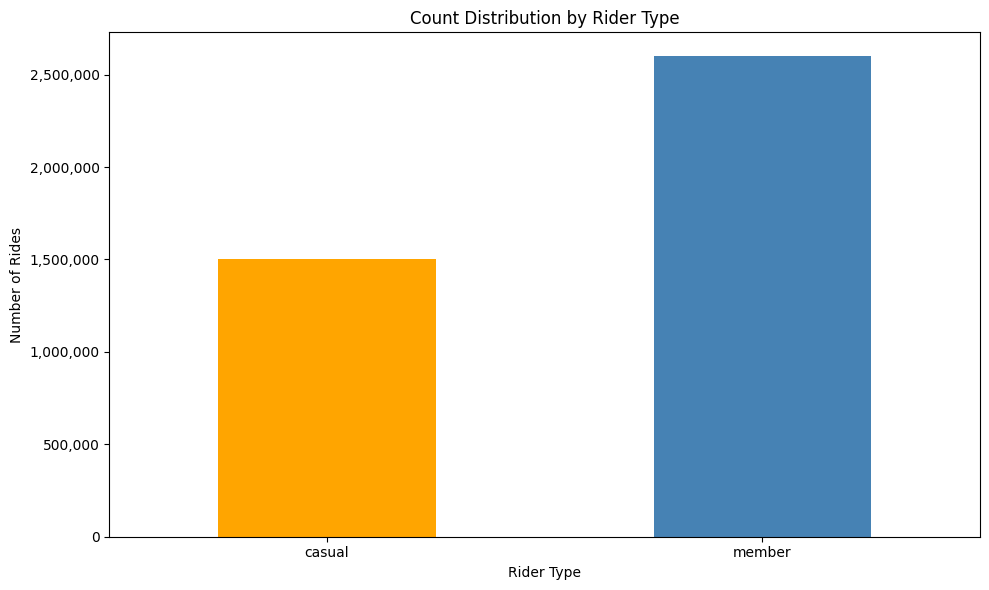

In [37]:
# Rider counts as bar chart

plt.figure(figsize = (6,4))

rider_counts.sort_index().plot(
    kind="bar",
    color=["orange","steelblue"],
    figsize = (10,6)
)

plt.title("Count Distribution by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    tckr.StrMethodFormatter('{x:,.0f}')
)

plt.tight_layout()
plt.show()

### Rider Type Percentages
---

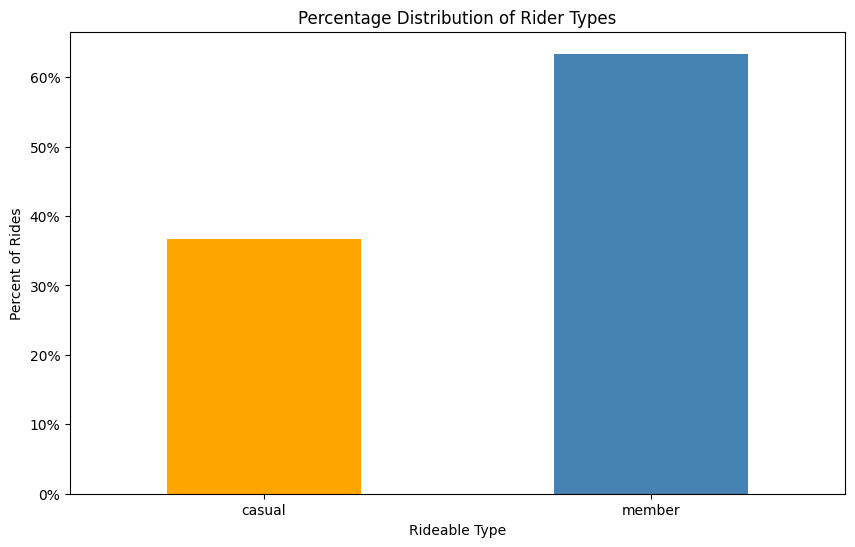

In [38]:
# Rider Percentage

ax = rider_percentage.sort_index().plot(
    kind="bar",
    color = ["orange", "steelblue"],
    figsize = (10,6)
)

plt.title("Percentage Distribution of Rider Types")
plt.xlabel("Rideable Type")
plt.ylabel("Percent of Rides")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:.0f}%'))
plt.show()

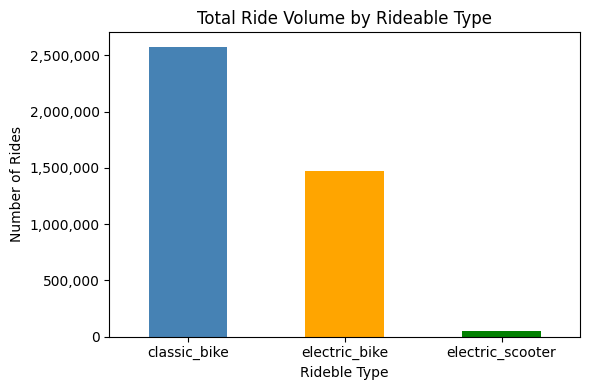

In [39]:
# Rideable Type Count 

plt.figure(figsize = (6,4))

rideables_count.plot(kind="bar", color=["steelblue", "orange", "green"])

plt.title("Total Ride Volume by Rideable Type")
plt.xlabel("Rideble Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    tckr.StrMethodFormatter('{x:,.0f}')
)

plt.tight_layout()
plt.show()

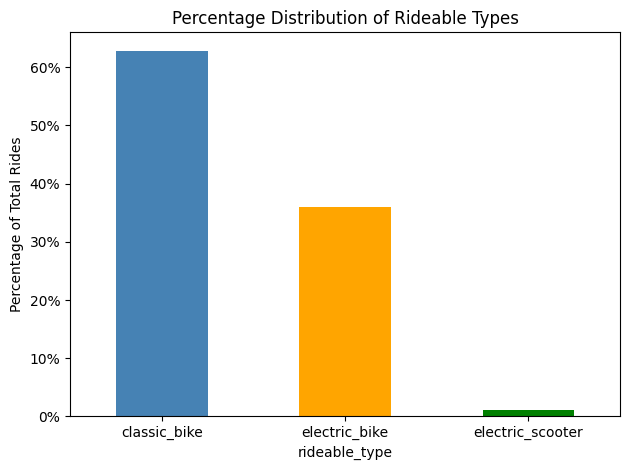

In [40]:
# Rideables Percentage
rideables_percentage.plot(
    kind="bar",
    color = ["steelblue", "orange", "green"]
)

plt.title("Percentage Distribution of Rideable Types")
plt.ylabel("Percentage of Total Rides")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}%'))
plt.tight_layout()
plt.show()

## 4.2 - Ride Duration Visualizations

Boxplot for Member type ride duration

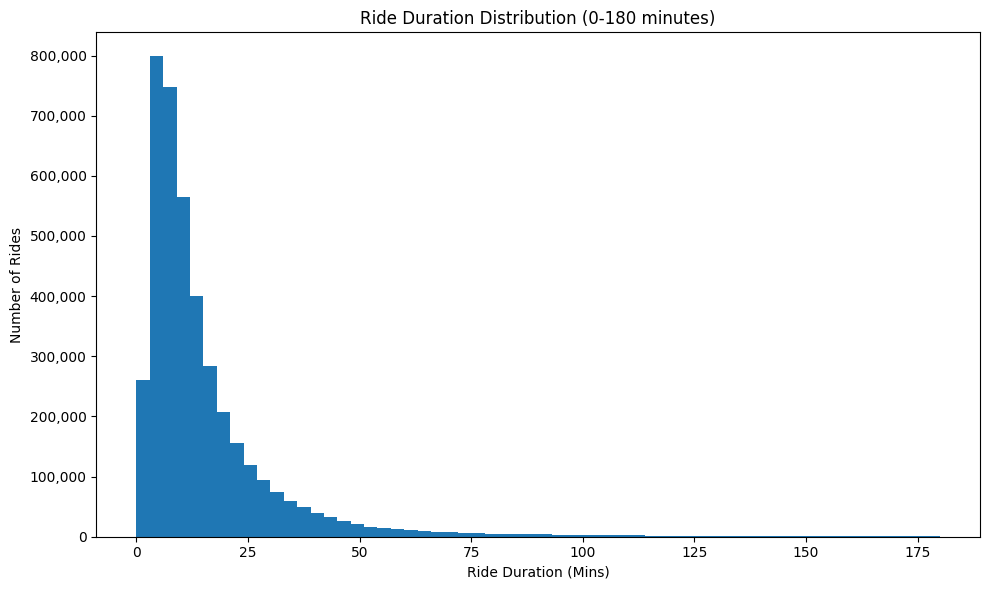

In [41]:
viz_cap = 180 # 3 hr limit for ride duration
duration_viz_df = duration_df[duration_df["ride_duration_mins"] <= viz_cap]

plt.figure(figsize = (10,6))
plt.hist(duration_viz_df["ride_duration_mins"], bins = 60)
plt.title(f"Ride Duration Distribution (0-{viz_cap} minutes)")
plt.xlabel("Ride Duration (Mins)")
plt.ylabel("Number of Rides")
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

### Ride Duration by Rider Type (Average)
---

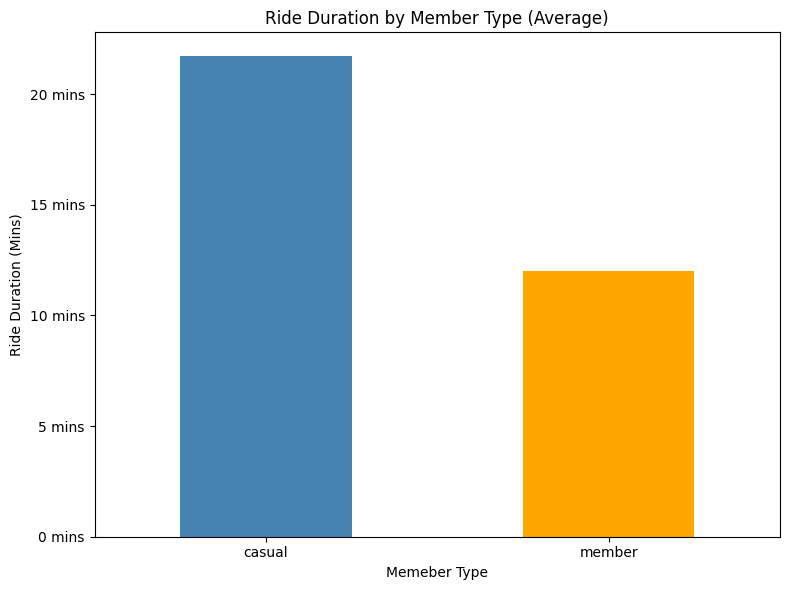

In [42]:
avg_duration_by_rider.plot(
    kind = "bar",
    color = ["steelblue","orange"], 
    figsize = (8,6)
)

plt.title("Ride Duration by Member Type (Average)")
plt.ylabel("Ride Duration (Mins)")
plt.xlabel("Memeber Type")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f} mins'))
plt.tight_layout()
plt.show()

### Ride Duration by Rider Type (Maximum)

### Duration by Rideable Type
---

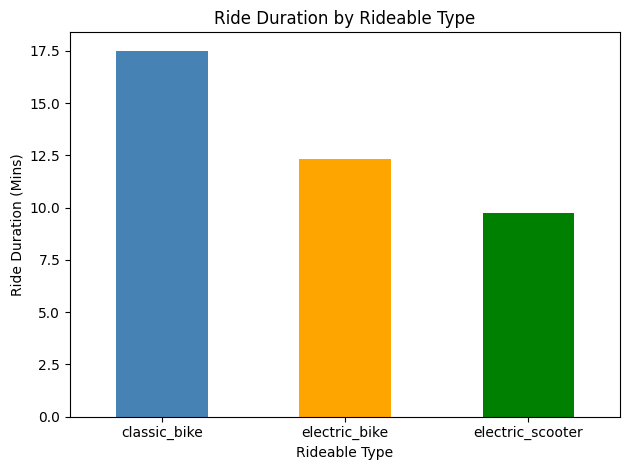

In [43]:
avg_duration_by_rideable.plot(kind = "bar", color = ["steelblue", "orange", "green"])

plt.title("Ride Duration by Rideable Type")
plt.ylabel("Ride Duration (Mins)")
plt.xlabel("Rideable Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.4 - Temporal Usage Visualizations
---

Histogram of Ride Duration in Mins & Box plot of ride duration in mins. 

### Ride Duration by Day of Week
---

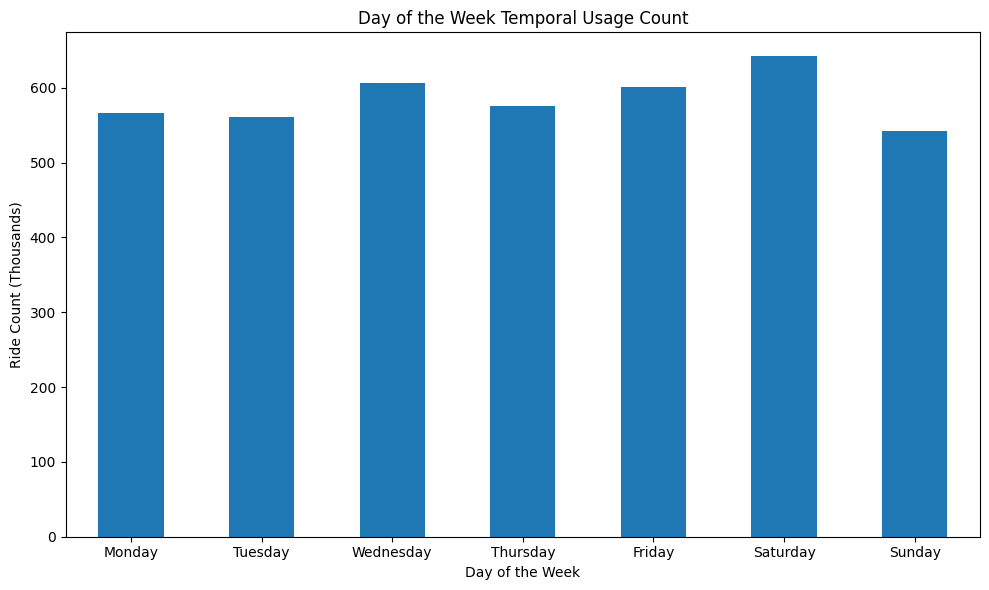

In [44]:
ax = day_of_week_count.plot(
    kind = "bar", 
    figsize = (10,6)
)
plt.title("Day of the Week Temporal Usage Count")
plt.xlabel("Day of the Week")
plt.ylabel("Ride Count (Thousands)")

ax.yaxis.set_major_formatter(tckr.FuncFormatter(lambda x, pos: f"{x/1000:,.0f}"))

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.5 - Temporal Usage Visualization

Grouped Bar Chart - rides by day of the week split by member type. (x = Mon- Sun (ordered), y = counts of member/casual types (2 bars per day)). 

Bar Chart - Weekday vs Weekend counts split by member type. 

Line Chart - monthly total rides over time (x = month, y = count). One line for total, two for member/casual group. 

Optional: Bar Chart - Total rides by Season (only if it adds something beyond warmer months being a higher trend). 

### Total Ride Volume by Hour
---

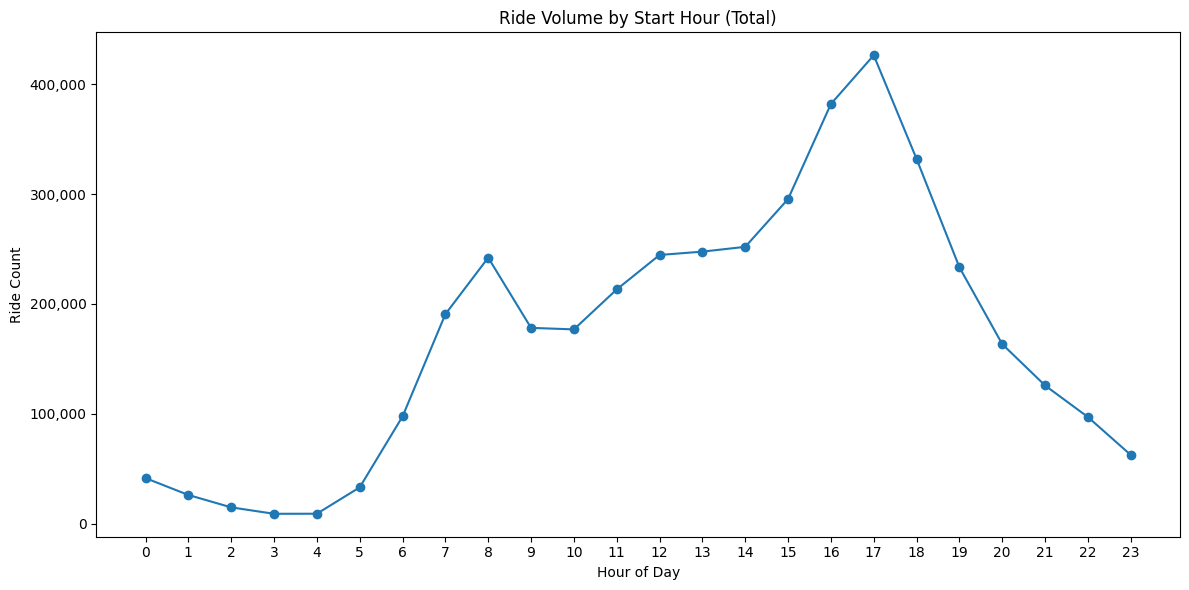

In [45]:
plt.figure(figsize = (12,6))
plt.plot(hourly_count.index, hourly_count.values, marker = "o")
plt.title("Ride Volume by Start Hour (Total)")
plt.xlabel("Hour of Day")
plt.ylabel("Ride Count")
plt.xticks(range(0,24))
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

### Hourly Ride Volume by Rider Type
---

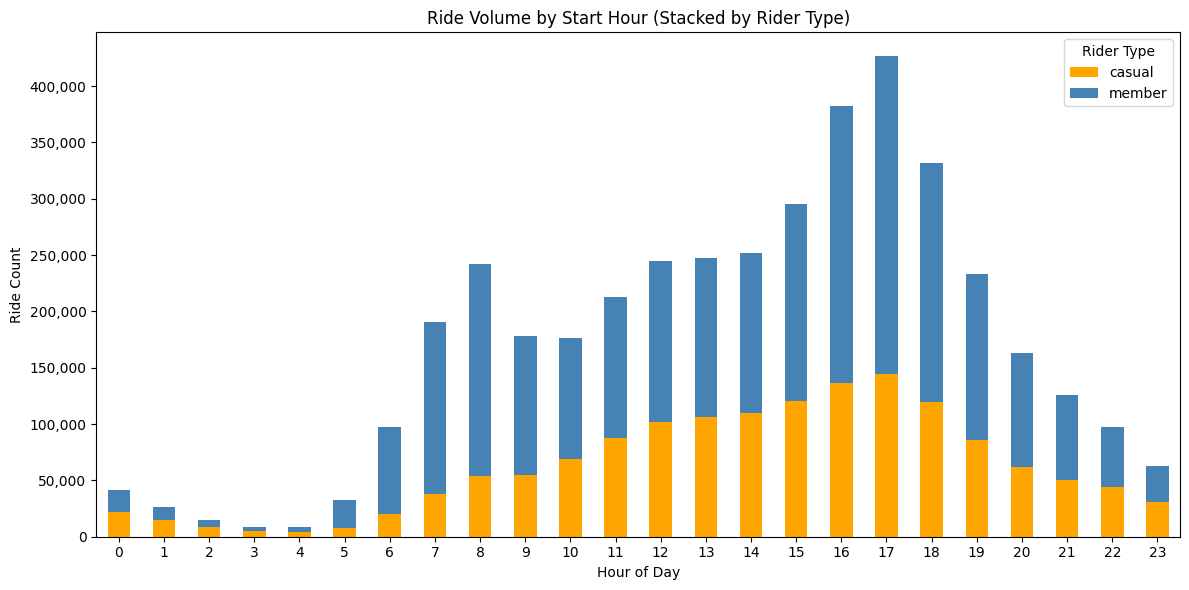

In [46]:
ax = hour_by_member.plot(kind = "bar", stacked = True, figsize = (12,6), color = ["orange", "steelblue"])
plt.title("Ride Volume by Start Hour (Stacked by Rider Type)")
plt.xlabel("Hour of Day")
plt.ylabel("Ride Count")
plt.xticks(rotation = 0)
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.legend(title = "Rider Type")
plt.tight_layout()
plt.show()

### Daypart Composition Percentage
---

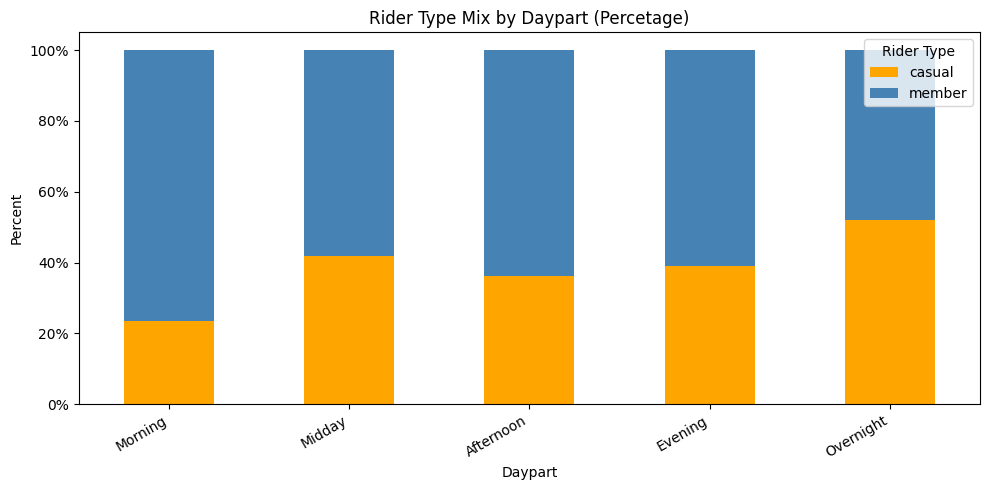

In [47]:
ax = daypart_by_member_pct.plot(kind = "bar", stacked = True, figsize = (10,5), color = ["orange", "steelblue"])
plt.title("Rider Type Mix by Daypart (Percetage)")
plt.xlabel("Daypart")
plt.ylabel("Percent")
plt.xticks(rotation = 30, ha = "right")
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:.0f}%'))
plt.legend(title = "Rider Type")
plt.tight_layout()
plt.show()

### Ride Count Day of the Week by Member Type
---

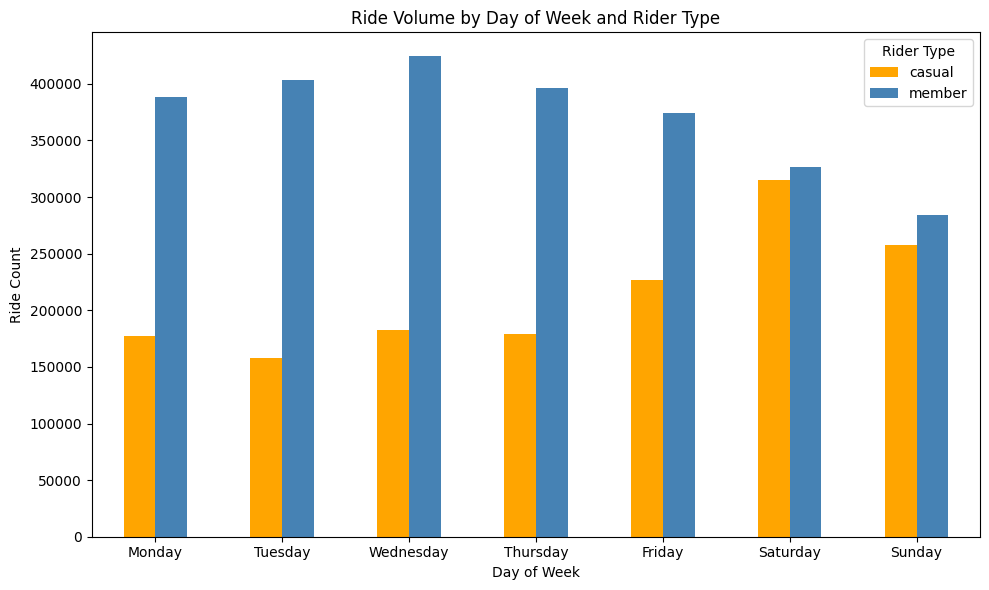

In [48]:
# Rides by Day of the Week grouped by Member Type

# Transpose the dow_rider_count for the chart. 

dow_rider_count_T = dow_rider_count.T

# Create the plot

dow_rider_count_T.plot(
    kind = "bar",
    figsize = (10,6),
    color = ["orange", "steelblue"])

plt.title("Ride Volume by Day of Week and Rider Type")
plt.xlabel("Day of Week")
plt.ylabel("Ride Count")

# Format the y-axis with commas

ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))

plt.legend(title = "Rider Type")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

### Weekday vs. Weekend Counts by Member Type
---

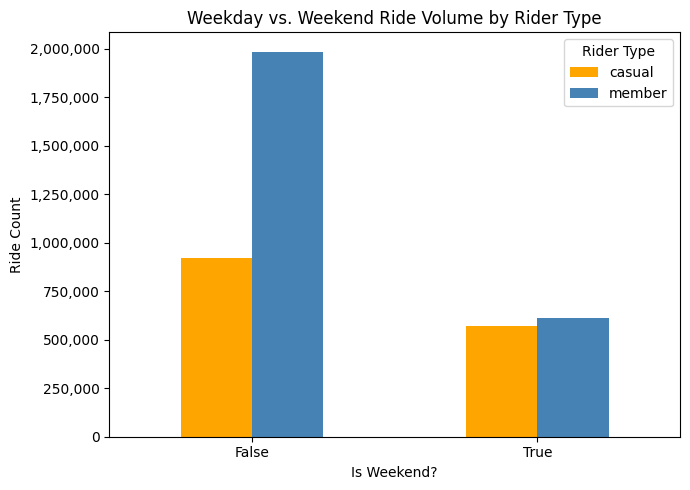

In [49]:
weekend_rider_count = pd.crosstab(duration_df["is_weekend"], duration_df["member_casual"])
# Order rows for readability
weekend_rider_count = weekend_rider_count.reindex([False,True])

ax = weekend_rider_count.plot(kind = "bar", figsize = (7,5), color = ["orange", "steelblue"])
plt.title("Weekday vs. Weekend Ride Volume by Rider Type")
plt.xlabel("Is Weekend?")
plt.ylabel("Ride Count")
plt.xticks(rotation = 0)
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.legend(title = "Rider Type")
plt.tight_layout()
plt.show()

### Monthly Ride Count
---

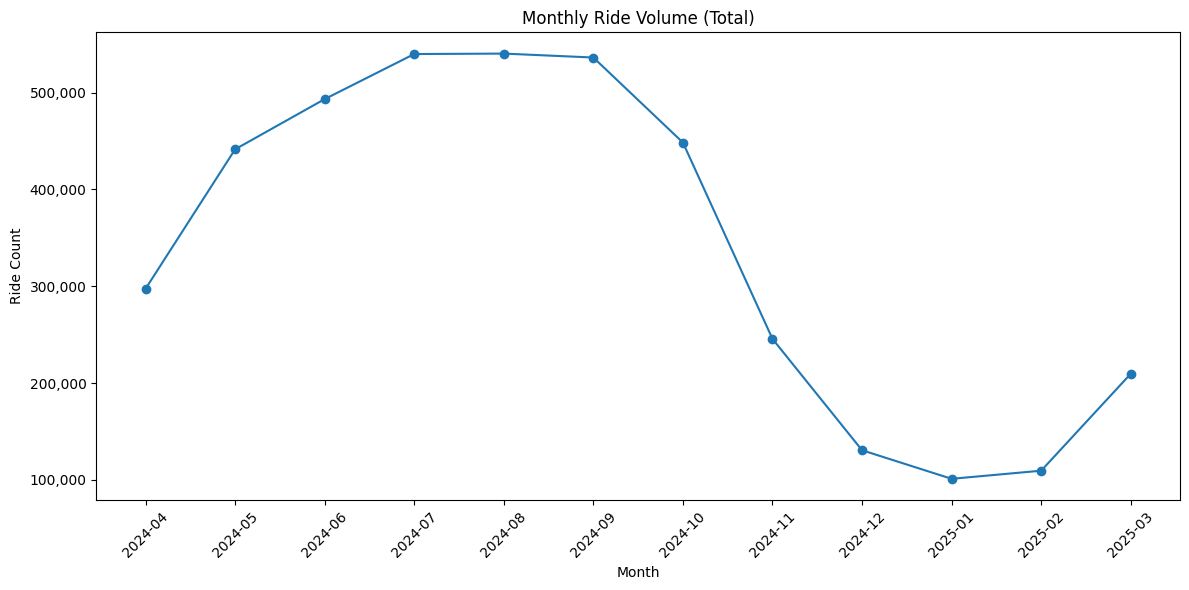

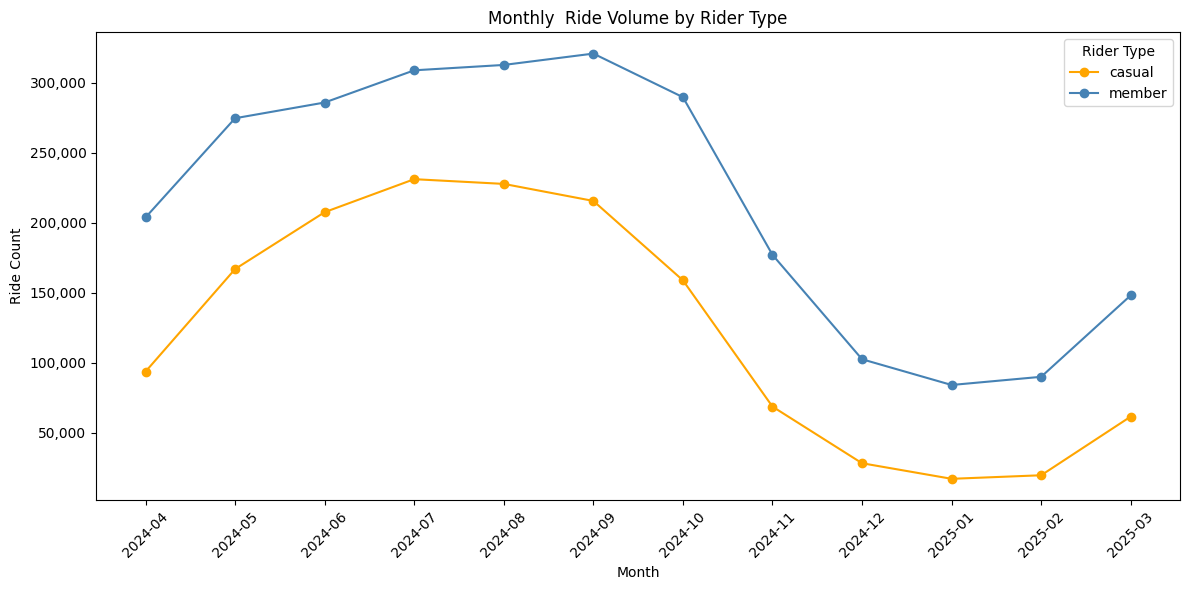

In [50]:
duration_df["month"] = duration_df["started_at"].dt.to_period("M").astype(str)

monthly_total = duration_df.groupby("month").size()
monthly_by_type = duration_df.groupby(["month", "member_casual"]).size().unstack(fill_value = 0)

plt.figure(figsize = (12,6))
plt.plot(monthly_total.index, monthly_total.values, marker = "o")
plt.title("Monthly Ride Volume (Total)")
plt.xlabel("Month")
plt.ylabel("Ride Count")
plt.xticks(rotation = 45)
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# By Rider Type

plt.figure(figsize = (12,6))
color_map = {
    "member": "steelblue",
    "casual": "orange"
}
for col in monthly_by_type.columns:
    plt.plot(monthly_by_type.index, monthly_by_type[col].values, marker = "o", label = col, color = color_map[col])
plt.title("Monthly  Ride Volume by Rider Type")
plt.xlabel("Month")
plt.ylabel("Ride Count")
plt.xticks(rotation = 45)
plt.gca().yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.legend(title = "Rider Type")
plt.tight_layout()
plt.show()

### Day of the Week by Rideable
---

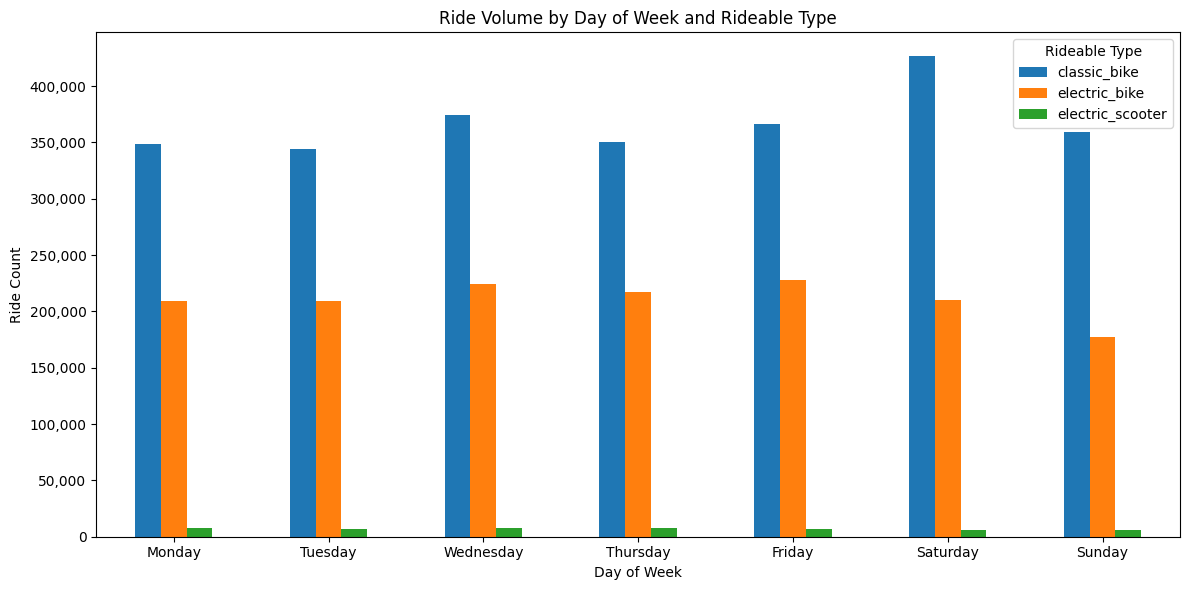

In [51]:
dow_rideable = pd.crosstab(duration_df["day_of_week"], duration_df["rideable_type"])
dow_rideable = dow_rideable.loc[dow_order] # Ensure they're in order. 

ax = dow_rideable.plot(kind = "bar", figsize = (12,6))
plt.title("Ride Volume by Day of Week and Rideable Type")
plt.xlabel("Day of Week")
plt.ylabel("Ride Count")
plt.xticks(rotation = 0)
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.legend(title = "Rideable Type")
plt.tight_layout()
plt.show()

### Seasonal Ride Count
---

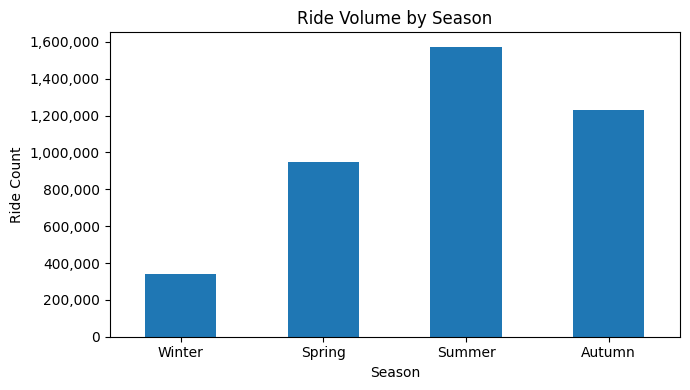

In [52]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_counts = duration_df["season"].value_counts().reindex(season_order)

ax = season_counts.plot(kind = "bar", figsize = (7,4))
plt.title("Ride Volume by Season")
plt.xlabel("Season")
plt.ylabel("Ride Count")
plt.xticks(rotation = 0)
ax.yaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

## 4.6 - Start/End Station Usage (Top 10)
---

Horizontal Bar Chart - Top 10 Stations (counts)

### Start Station Usage by Ride Count
---

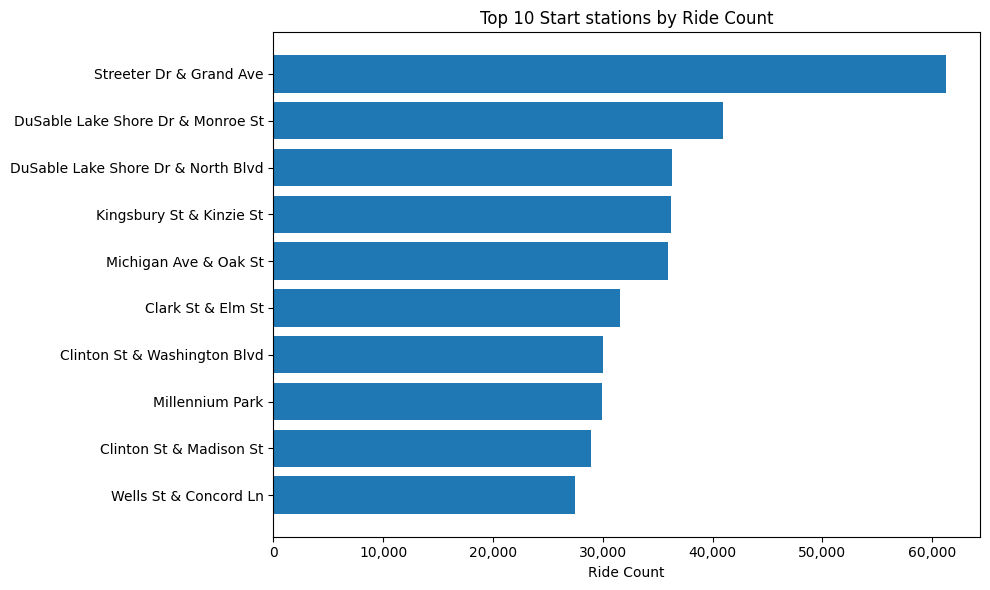

In [53]:
top_n = 10

top_start = duration_df["start_station_name"].value_counts().head(top_n).sort_values()
plt.figure(figsize = (10,6))
plt.barh(top_start.index, top_start.values)
plt.title(f"Top {top_n} Start stations by Ride Count")
plt.xlabel("Ride Count")
plt.gca().xaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

### End Station Usage by Ride Count
---

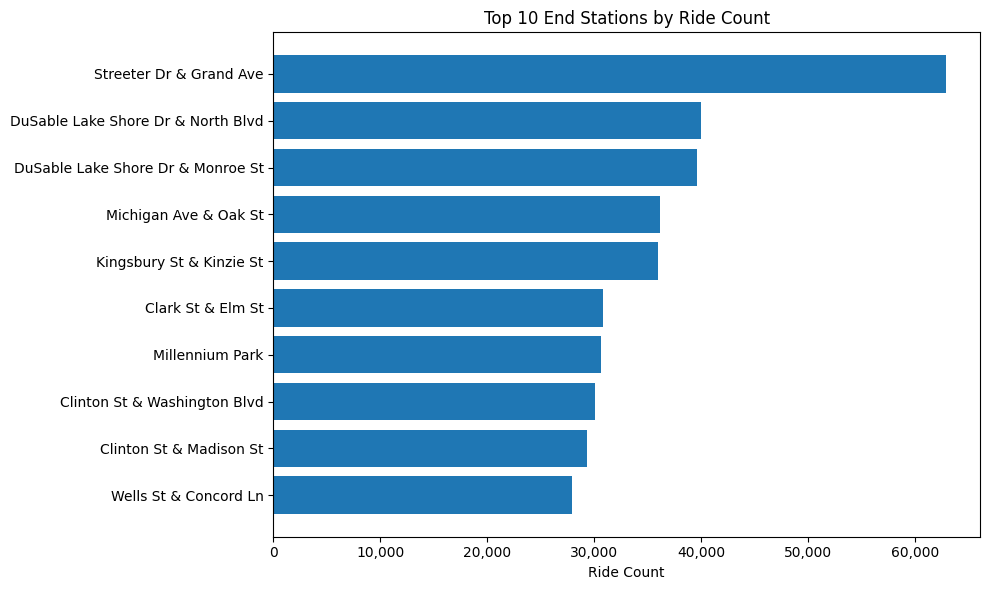

In [54]:
top_end = duration_df["end_station_name"].value_counts().head(top_n).sort_values()
plt.figure(figsize = (10,6))
plt.barh(top_end.index, top_end.values)
plt.title(f"Top {top_n} End Stations by Ride Count")
plt.xlabel("Ride Count")
plt.gca().xaxis.set_major_formatter(tckr.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# Step 5. Conclusions
___

In conclusion, there are three major findings: 

1. Members make up (63%) of rides, but casual riders take longer rides on average (an average of 24 minutes), indicating different usage patterns between the two groups. 
2. Classic bikes dominate the total ride volume, while electric scooters make up a very small portion of overall usage.
3. Ride demand peaks during commute-like hours, especially in the morning and late afternoon, which is consistent with routine member usage.
4. Casual riders become much more prominent on Fridays and the weekends, supporting the idea that they use the service more recreationally than members.
6. Ridership is strongly seasonal, tapering off in the Winter, and peaking in the Summer.
7. A relatively small set of stations accounts for a large share of ride counts as both starting and ending points, making them strong candidates for focused marketing visibility. 

## Recommendations 

Given this data, I'd recommend focusing on: 

#### Weekend Conversion Campaigns

Advertising targeting casual riders on Friday, Saturday and Sundays with membership trial offers could prove to be effective in bolstering member numbers. 

#### Focus on Classic Bike Positioning

It's evident that classic bikes dominate the rideable type volumes, as such, marketing should lean into this and promote that experience over electric bikes and scooters. 

#### Station Focus

Per the last two visualizations of the top 10 starting and ending stations. Focusing promotional/marketing material at these tops stations (and possibly top corridors) will likely yield the higest exposure among riders. 

## Limitations

It's worth noting that I biased the data towards docked rides and fully complete station records (i.e. dropping rows with extensive ride times beyond, and removing rows with missing missing stations in either the start or end station). 

I also excluded non-positive ride durations entirely, as these provide no value to the project. 

Lastly, I limited this project to descriptive statistics and exploratory data analysis of ride times, counts, and statistical frequencies.

While it is possible to implement demographic and weather data into the analysis, this is forgone at this time. 